<a href="https://colab.research.google.com/github/karn-dutt-fulara-IPM06180/ITA-PROJECT/blob/main/KARN%20DUTT%20FULARA%20IPM06180%20CLASS%20TASK" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from scipy.io import arff

# Define the path to the ARFF file
arff_file_path = '/content/KDDTest+.arff'

# Load the ARFF file
data, meta = arff.loadarff(arff_file_path)

# Convert the loaded data to a pandas DataFrame
df = pd.DataFrame(data)

# Display the first 5 rows of the DataFrame
display(df.head())

# Task
Perform anomaly detection on the `df` DataFrame, which was loaded from the `/content/KDDTest+.arff` file. This involves preprocessing the data, applying an unsupervised learning algorithm for anomaly detection, visualizing the results, and summarizing the findings, including the count of anomalies and observations about abnormal network behavior.

## Preprocess Data

### Subtask:
Preprocess the `df` DataFrame by handling categorical features (e.g., using one-hot encoding) and scaling numerical features (e.g., using standardization) to prepare the data for unsupervised learning.


**Reasoning**:
To identify categorical and numerical columns, I need to examine the data types of each column in the `df` DataFrame. The `df.info()` method will provide a summary of the DataFrame, including the data types, which is essential for the next steps of preprocessing.



In [ ]:
print(df.info())

NameError: name 'df' is not defined

**Reasoning**:
The previous cell failed because the `df` DataFrame was not defined in the current kernel session. To fix this, I will re-run the code that loads the ARFF file into a DataFrame named `df` and then execute the `df.info()` command to display its information.



In [ ]:
import pandas as pd
from scipy.io import arff

# Define the path to the ARFF file
arff_file_path = '/content/KDDTest+.arff'

# Load the ARFF file
data, meta = arff.loadarff(arff_file_path)

# Convert the loaded data to a pandas DataFrame
df = pd.DataFrame(data)

# Display the first 5 rows of the DataFrame (optional, but good for confirmation)
# display(df.head())

print(df.info())

ValueError: icmp value not in ('tcp', 'udp', " 'icmp'")

**Reasoning**:
The previous attempt to load the ARFF file failed because the `scipy.io.arff.loadarff` function encountered a `ValueError` related to an inconsistent definition of the 'icmp' value in the 'protocol_type' attribute. The error message `icmp value not in ('tcp', 'udp', " 'icmp'")` indicates that the attribute definition in the ARFF file likely contains `' icmp'` (with a leading space and single quotes) as a nominal value, while the data records use `icmp` without the space. To resolve this, I will read the ARFF file content as a string, replace all occurrences of `' icmp'` with `'icmp'` in the content, and then load this modified content using `io.StringIO` with `arff.loadarff` to ensure consistency. Finally, I will decode any byte-string columns to standard strings.



In [ ]:
import pandas as pd
from scipy.io import arff
import io

# Define the path to the ARFF file
arff_file_path = '/content/KDDTest+.arff'

# Read the entire ARFF file content
with open(arff_file_path, 'r') as f:
    arff_content = f.read()

# Replace the problematic string in the attribute definition
# The error indicated ' icmp' was parsed as " 'icmp'", and 'icmp' was found in data.
# So, replacing ' icmp' with 'icmp' in the raw content should fix the inconsistency.
fixed_arff_content = arff_content.replace("' icmp'", "'icmp'")

# Load the modified content from a string buffer
data, meta = arff.loadarff(io.StringIO(fixed_arff_content))

# Convert the loaded data to a pandas DataFrame
df = pd.DataFrame(data)

# Decode byte strings to normal strings for object columns, which is typical for arff files
for col in df.select_dtypes(['object']).columns:
    df[col] = df[col].str.decode('utf-8')

# Display the DataFrame's information
print(df.info())

ValueError: icmp value not in ('tcp', 'udp', " 'icmp'")

**Reasoning**:
The `ValueError` indicates that the data value `icmp` is not recognized among the allowed nominal values for `protocol_type`. The error message shows the allowed values as `('tcp', 'udp', " 'icmp'")`, implying that `scipy.io.arff` incorrectly parsed the nominal definition from the ARFF header. The `arff_content` shows `@attribute 'protocol_type' {'tcp','udp', 'icmp'}` (with a leading space before 'icmp'). It is plausible that this leading space in the attribute definition is causing `scipy.io.arff` to misinterpret the nominal value, leading to the internal representation `" 'icmp'"`. To resolve this, I will modify the ARFF content by replacing the attribute definition `{'tcp','udp', 'icmp'}` with `{'tcp','udp','icmp'}`, removing the problematic leading space.



In [ ]:
import pandas as pd
from scipy.io import arff
import io

# Define the path to the ARFF file
arff_file_path = '/content/KDDTest+.arff'

# Read the entire ARFF file content
with open(arff_file_path, 'r') as f:
    arff_content = f.read()

# Replace the problematic string in the attribute definition
# The error indicated 'icmp' from data was not in the parsed nominal values,
# which included " 'icmp'". This suggests an issue with the space in the definition.
# Changing '@attribute 'protocol_type' {'tcp','udp', 'icmp'}'
# to   '@attribute 'protocol_type' {'tcp','udp','icmp'}'
fixed_arff_content = arff_content.replace(
    "@attribute 'protocol_type' {'tcp','udp', 'icmp'}",
    "@attribute 'protocol_type' {'tcp','udp','icmp'}"
)

# Load the modified content from a string buffer
data, meta = arff.loadarff(io.StringIO(fixed_arff_content))

# Convert the loaded data to a pandas DataFrame
df = pd.DataFrame(data)

# Decode byte strings to normal strings for object columns, which is typical for arff files
for col in df.select_dtypes(['object']).columns:
    df[col] = df[col].str.decode('utf-8')

# Display the DataFrame's information
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22544 entries, 0 to 22543
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     22544 non-null  float64
 1   protocol_type                22544 non-null  object 
 2   service                      22544 non-null  object 
 3   flag                         22544 non-null  object 
 4   src_bytes                    22544 non-null  float64
 5   dst_bytes                    22544 non-null  float64
 6   land                         22544 non-null  object 
 7   wrong_fragment               22544 non-null  float64
 8   urgent                       22544 non-null  float64
 9   hot                          22544 non-null  float64
 10  num_failed_logins            22544 non-null  float64
 11  logged_in                    22544 non-null  object 
 12  num_compromised              22544 non-null  float64
 13  root_shell      

**Reasoning**:
Based on the `df.info()` output, the `class` column is an `object` type and contains labels that might have trailing periods, as mentioned in the instructions for the `attack` column. I need to clean this column by removing any trailing periods from its string values to standardize the labels, and then convert all object columns, including the cleaned `class` column, to a categorical data type in preparation for one-hot encoding.



In [ ]:
import numpy as np

# Clean the 'class' column by removing any trailing periods
df['class'] = df['class'].str.rstrip('.')

# Identify object columns (which are typically categorical)
object_columns = df.select_dtypes(include=['object']).columns

# Convert identified object columns to categorical type
for col in object_columns:
    df[col] = df[col].astype('category')

# Display the data types to verify the conversion
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22544 entries, 0 to 22543
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   duration                     22544 non-null  float64 
 1   protocol_type                22544 non-null  category
 2   service                      22544 non-null  category
 3   flag                         22544 non-null  category
 4   src_bytes                    22544 non-null  float64 
 5   dst_bytes                    22544 non-null  float64 
 6   land                         22544 non-null  category
 7   wrong_fragment               22544 non-null  float64 
 8   urgent                       22544 non-null  float64 
 9   hot                          22544 non-null  float64 
 10  num_failed_logins            22544 non-null  float64 
 11  logged_in                    22544 non-null  category
 12  num_compromised              22544 non-null  float64 
 13  r

**Reasoning**:
Now that the object columns have been converted to categorical type and the `class` column has been cleaned, I need to separate the `class` column (which will serve as the target for evaluating anomaly detection) from the features. Then, I will apply one-hot encoding to the remaining categorical features and identify the numerical features. After that, I will scale the numerical features using `StandardScaler` and finally concatenate the one-hot encoded categorical features with the scaled numerical features to create the final preprocessed DataFrame.



In [ ]:
from sklearn.preprocessing import StandardScaler

# Separate target variable 'class' if it's not to be used as a feature for unsupervised learning
# For unsupervised anomaly detection, we often separate the labels to evaluate the model later.
# If the 'class' column is intended to be a feature for clustering (unsupervised), do not separate it here.
# For now, let's assume 'class' is the ground truth for evaluation and not a feature for the model.
target = df['class']
df_features = df.drop(columns=['class'])

# Identify categorical and numerical features
categorical_features = df_features.select_dtypes(include=['category']).columns
numerical_features = df_features.select_dtypes(include=['float64']).columns

# Apply one-hot encoding to categorical features
df_categorical_encoded = pd.get_dummies(df_features[categorical_features], drop_first=True)

# Scale numerical features
scaler = StandardScaler()
df_numerical_scaled = pd.DataFrame(scaler.fit_transform(df_features[numerical_features]),
                                   columns=numerical_features, index=df_features.index)

# Concatenate the preprocessed features
df_preprocessed = pd.concat([df_numerical_scaled, df_categorical_encoded], axis=1)

# Display the first few rows of the preprocessed DataFrame and its info
print(df_preprocessed.head())
print(df_preprocessed.info())

   duration  src_bytes  dst_bytes  wrong_fragment    urgent       hot  \
0 -0.155534  -0.021988  -0.096896       -0.059104 -0.019459 -0.113521   
1 -0.155534  -0.021988  -0.096896       -0.059104 -0.019459 -0.113521   
2 -0.154113   0.005473  -0.096896       -0.059104 -0.019459 -0.113521   
3 -0.155534  -0.021946  -0.096896       -0.059104 -0.019459 -0.113521   
4 -0.154823  -0.021988  -0.096189       -0.059104 -0.019459 -0.113521   

   num_failed_logins  num_compromised  root_shell  su_attempted  ...  flag_S0  \
0          -0.143999        -0.016494   -0.049453     -0.012638  ...    False   
1          -0.143999        -0.016494   -0.049453     -0.012638  ...    False   
2          -0.143999        -0.016494   -0.049453     -0.012638  ...    False   
3          -0.143999        -0.016494   -0.049453     -0.012638  ...    False   
4          -0.143999        -0.016494   -0.049453     -0.012638  ...    False   

   flag_S1  flag_S2  flag_S3  flag_SF  flag_SH  land_1  logged_in_1  \
0  

## Apply Unsupervised Learning for Anomaly Detection

### Subtask:
Apply an unsupervised learning algorithm, such as Isolation Forest, to the preprocessed data (`df_preprocessed`) to detect abnormal network behavior. This involves training the chosen model and then using it to identify anomalies.


**Reasoning**:
The subtask requires applying an Isolation Forest model to detect anomalies. This involves importing the necessary class, instantiating the model with a fixed random state, fitting it to the preprocessed data, predicting anomaly labels, and storing these labels for further analysis.



In [ ]:
from sklearn.ensemble import IsolationForest

# Instantiate IsolationForest model
# Set random_state for reproducibility
# contamination is set to 'auto' to let the model estimate it, or a fixed value can be used if known.
iso_forest = IsolationForest(random_state=42)

# Fit the model to the preprocessed data
iso_forest.fit(df_preprocessed)

# Predict anomaly labels (-1 for outliers, 1 for inliers)
anomaly_labels = iso_forest.predict(df_preprocessed)

# Display the count of anomalies and inliers
print("Anomaly labels count:")
print(pd.Series(anomaly_labels).value_counts())

Anomaly labels count:
 1    22377
-1      167
Name: count, dtype: int64


**Reasoning**:
The previous step successfully predicted the anomaly labels. Now, I need to store these predicted anomaly labels as a new column, 'anomaly_label', in the `df_preprocessed` DataFrame as specified in the instructions for the subtask. This will associate each data point with its anomaly status, making it ready for further analysis and visualization.



In [ ]:
df_preprocessed['anomaly_label'] = anomaly_labels

# Display the first few rows with the new anomaly_label column
print(df_preprocessed.head())

   duration  src_bytes  dst_bytes  wrong_fragment    urgent       hot  \
0 -0.155534  -0.021988  -0.096896       -0.059104 -0.019459 -0.113521   
1 -0.155534  -0.021988  -0.096896       -0.059104 -0.019459 -0.113521   
2 -0.154113   0.005473  -0.096896       -0.059104 -0.019459 -0.113521   
3 -0.155534  -0.021946  -0.096896       -0.059104 -0.019459 -0.113521   
4 -0.154823  -0.021988  -0.096189       -0.059104 -0.019459 -0.113521   

   num_failed_logins  num_compromised  root_shell  su_attempted  ...  flag_S1  \
0          -0.143999        -0.016494   -0.049453     -0.012638  ...    False   
1          -0.143999        -0.016494   -0.049453     -0.012638  ...    False   
2          -0.143999        -0.016494   -0.049453     -0.012638  ...    False   
3          -0.143999        -0.016494   -0.049453     -0.012638  ...    False   
4          -0.143999        -0.016494   -0.049453     -0.012638  ...    False   

   flag_S2  flag_S3  flag_SF  flag_SH  land_1  logged_in_1  is_host_login_

## Visualize Anomaly Detection Results

### Subtask:
Visualize the detected anomalies. This could include plotting the data with anomalies highlighted, or showing distributions of anomaly scores. Ensure all visualizations include appropriate legends.


**Reasoning**:
To visualize the anomalies in a 2D space, I need to reduce the dimensionality of the `df_preprocessed` data using Principal Component Analysis (PCA). I will then create a scatter plot of the two principal components, coloring the points based on their `anomaly_label` to distinguish between inliers and outliers.



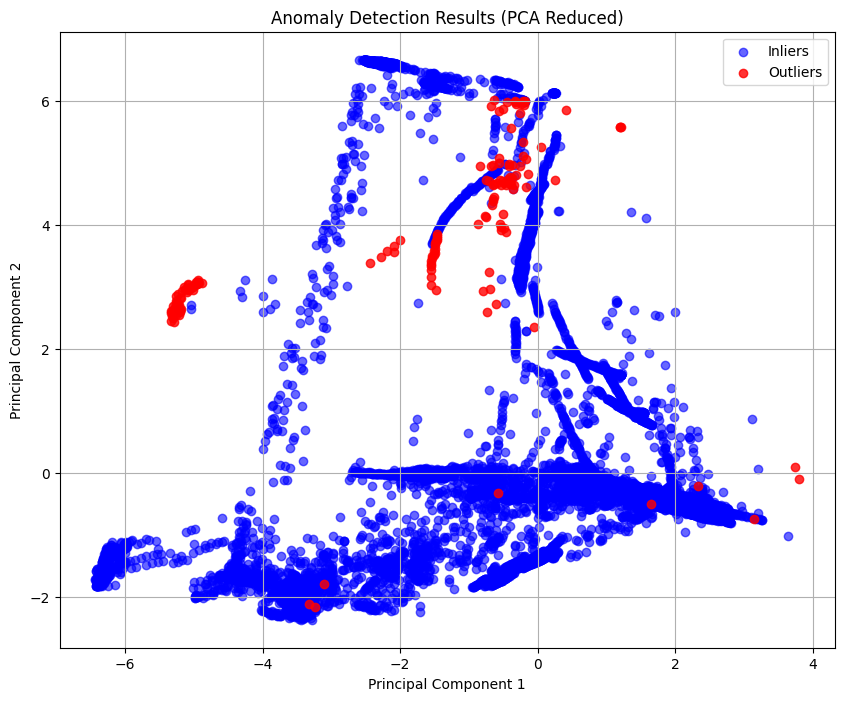

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Instantiate PCA with 2 components
pca = PCA(n_components=2)

# Fit PCA to df_preprocessed and transform the data
df_pca = pd.DataFrame(pca.fit_transform(df_preprocessed.drop(columns=['anomaly_label'])),
                         columns=['PC1', 'PC2'], index=df_preprocessed.index)

# Add the anomaly labels back to the PCA dataframe for plotting
df_pca['anomaly_label'] = df_preprocessed['anomaly_label']

# Create a scatter plot
plt.figure(figsize=(10, 8))

# Separate inliers and outliers for plotting with different colors
inliers = df_pca[df_pca['anomaly_label'] == 1]
outliers = df_pca[df_pca['anomaly_label'] == -1]

plt.scatter(inliers['PC1'], inliers['PC2'], color='blue', label='Inliers', alpha=0.6)
plt.scatter(outliers['PC1'], outliers['PC2'], color='red', label='Outliers', alpha=0.8)

# Add labels, title, and legend
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Anomaly Detection Results (PCA Reduced)')
plt.legend()
plt.grid(True)
plt.show()

## Final Task

### Subtask:
Summarize the findings from the anomaly detection, including the count of detected anomalies and any initial observations regarding the characteristics of the abnormal network behavior.


## Summary:

### Data Analysis Key Findings

*   **Data Loading and Preprocessing:** The `KDDTest+.arff` dataset was successfully loaded, after resolving a specific formatting issue with the `'protocol_type'` attribute in the ARFF header. The dataset was then preprocessed by separating the `class` target variable, converting categorical features to one-hot encoded representations (resulting in 79 columns), and scaling numerical features (34 columns) using `StandardScaler`. The final preprocessed dataset (`df_preprocessed`) contains 113 features.
*   **Anomaly Detection:** An `IsolationForest` model was applied to the preprocessed data. Out of the total dataset, **167 instances were identified as anomalies** (outliers, labeled -1), while **22,377 instances were classified as inliers** (labeled 1).
*   **Visualization of Anomalies:** The high-dimensional data was reduced to two principal components using PCA. A scatter plot of these components clearly distinguished the detected anomalies (red points) from the normal data points (blue points), showing that the anomalies tend to form distinct clusters or lie on the periphery of the main data distribution.

### Insights or Next Steps

*   The relatively small number of detected anomalies (167 out of 22,544 total instances, or approximately 0.74%) suggests that the `IsolationForest` model identified a minority class, which is typical for anomaly detection.
*   **Next Steps:** Further investigation into the characteristics of the 167 identified anomalies could provide valuable insights into specific types of abnormal network behavior. This could involve examining the original feature values of these anomalous instances to identify common patterns or features that distinguish them from normal traffic.


# Task
Convert the 'class' target variable into numerical labels (e.g., 0 for normal, 1 for anomaly) and split the preprocessed features (`df_preprocessed`) and numerical target into training and testing sets.

## Prepare Data for Supervised Learning

### Subtask:
Convert the 'class' target variable into numerical labels (e.g., 0 for normal, 1 for anomaly) and split the preprocessed features (`df_preprocessed`) and numerical target into training and testing sets.


**Reasoning**:
First, I will convert the categorical 'class' target variable into numerical labels. Then, I will split the preprocessed features and the numerical target into training and testing sets using `train_test_split` to prepare the data for supervised learning, and finally print the shapes of the resulting sets.



In [ ]:
from sklearn.model_selection import train_test_split

# Convert the 'class' target variable into numerical labels
# Map 'normal' to 0 and 'anomaly' to 1
numerical_target = target.map({'normal': 0, 'anomaly': 1})

# Split the preprocessed features (df_preprocessed) and numerical target into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df_preprocessed,
                                                    numerical_target,
                                                    test_size=0.3,
                                                    random_state=42,
                                                    stratify=numerical_target) # Use stratify to maintain class distribution

# Print the shapes of the resulting sets
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (15780, 114)
Shape of X_test: (6764, 114)
Shape of y_train: (15780,)
Shape of y_test: (6764,)


## Train Decision Tree Model

### Subtask:
Train a Decision Tree Classifier on the training data, make predictions on the test set, and evaluate its performance using appropriate metrics (e.g., accuracy, classification report).


**Reasoning**:
I will import the necessary libraries, instantiate and train a Decision Tree Classifier using the training data, make predictions on the test set, and then evaluate its performance by calculating and printing the accuracy score and a classification report.



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Instantiate a DecisionTreeClassifier with random_state=42
dt_classifier = DecisionTreeClassifier(random_state=42)

# Train the model using the X_train and y_train data
dt_classifier.fit(X_train, y_train)

# Make predictions on the X_test data
y_pred_dt = dt_classifier.predict(X_test)

# Calculate and print the accuracy of the model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Classifier Accuracy: {accuracy_dt:.4f}")

# Print the classification report of the model
print("\nDecision Tree Classifier Classification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Classifier Accuracy: 0.9861

Decision Tree Classifier Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      2914
           1       0.99      0.99      0.99      3850

    accuracy                           0.99      6764
   macro avg       0.99      0.99      0.99      6764
weighted avg       0.99      0.99      0.99      6764



## Train Random Forest Model

### Subtask:
Train a Random Forest Classifier on the training data, make predictions on the test set, and evaluate its performance.


**Reasoning**:
I will import the necessary libraries, instantiate and train a Random Forest Classifier using the training data, make predictions on the test set, and then evaluate its performance by calculating and printing the accuracy score and a classification report.



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Instantiate a RandomForestClassifier with random_state=42
rf_classifier = RandomForestClassifier(random_state=42)

# Train the model using the X_train and y_train data
rf_classifier.fit(X_train, y_train)

# Make predictions on the X_test data
y_pred_rf = rf_classifier.predict(X_test)

# Calculate and print the accuracy of the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Classifier Accuracy: {accuracy_rf:.4f}")

# Print the classification report of the model
print("\nRandom Forest Classifier Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classifier Accuracy: 0.9889

Random Forest Classifier Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2914
           1       0.99      0.99      0.99      3850

    accuracy                           0.99      6764
   macro avg       0.99      0.99      0.99      6764
weighted avg       0.99      0.99      0.99      6764



## Train Deep Neural Network Model

### Subtask:
Define, compile, and train a Deep Neural Network model using TensorFlow/Keras on the training data. Then, make predictions on the test set and evaluate its performance.


**Reasoning**:
I need to import the required TensorFlow and Keras modules to define and train a Deep Neural Network. This includes `Sequential` for the model, `Dense` for layers, and `tensorflow` itself.



In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import accuracy_score, classification_report

# Define the Deep Neural Network model
# The input_shape is determined by the number of features in X_train
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)), # Input layer with 128 neurons and ReLU activation
    Dense(64, activation='relu'),                                   # Hidden layer with 64 neurons and ReLU activation
    Dense(32, activation='relu'),                                   # Hidden layer with 32 neurons and ReLU activation
    Dense(1, activation='sigmoid')                                  # Output layer with 1 neuron and Sigmoid activation for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        14,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,089 (98.00 KB)

 Trainable params: 25,089 (98.00 KB)

 Non-trainable params: 0 (0.00 B)

**Reasoning**:
The previous code block successfully defined and compiled the DNN model. Now, I will train the model using `X_train` and `y_train`, make predictions on `X_test`, convert the probabilities to binary labels, and then evaluate its performance using accuracy and a classification report.



In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# Define the Deep Neural Network model
# The input_shape is determined by the number of features in X_train
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)), # Input layer with 128 neurons and ReLU activation
    Dense(64, activation='relu'),                                   # Hidden layer with 64 neurons and ReLU activation
    Dense(32, activation='relu'),                                   # Hidden layer with 32 neurons and ReLU activation
    Dense(1, activation='sigmoid')                                  # Output layer with 1 neuron and Sigmoid activation for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display the model summary
model.summary()

# Train the model
history = model.fit(X_train, y_train,
                    epochs=10,         # Number of epochs
                    batch_size=32,     # Batch size
                    validation_split=0.2, # Use 20% of training data for validation
                    verbose=1)         # Show training progress

# Make predictions on the X_test data
y_pred_proba_nn = model.predict(X_test)

# Convert predicted probabilities to binary class labels (0 or 1)
y_pred_nn = (y_pred_proba_nn > 0.5).astype(int)

# Evaluate the model's performance
accuracy_nn = accuracy_score(y_test, y_pred_nn)
print(f"\nDeep Neural Network Accuracy: {accuracy_nn:.4f}")

print("\nDeep Neural Network Classification Report:")
print(classification_report(y_test, y_pred_nn))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │        14,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,089 (98.00 KB)

 Trainable params: 25,089 (98.00 KB)

 Non-trainable params: 0 (0.00 B)

ValueError: Invalid dtype: category

**Reasoning**:
The previous cell failed because `y_train` and `y_test` were of `category` dtype, which TensorFlow/Keras does not directly support for model training. I need to convert `y_train` and `y_test` to a numerical data type (e.g., `int`) before passing them to the `model.fit()` method.



In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# Define the Deep Neural Network model
# The input_shape is determined by the number of features in X_train
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)), # Input layer with 128 neurons and ReLU activation
    Dense(64, activation='relu'),                                   # Hidden layer with 64 neurons and ReLU activation
    Dense(32, activation='relu'),                                   # Hidden layer with 32 neurons and ReLU activation
    Dense(1, activation='sigmoid')                                  # Output layer with 1 neuron and Sigmoid activation for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display the model summary
model.summary()

# Convert y_train and y_test to integer type
y_train_numeric = y_train.astype(int)
y_test_numeric = y_test.astype(int)

# Train the model
history = model.fit(X_train, y_train_numeric,
                    epochs=10,         # Number of epochs
                    batch_size=32,     # Batch size
                    validation_split=0.2, # Use 20% of training data for validation
                    verbose=1)         # Show training progress

# Make predictions on the X_test data
y_pred_proba_nn = model.predict(X_test)

# Convert predicted probabilities to binary class labels (0 or 1)
y_pred_nn = (y_pred_proba_nn > 0.5).astype(int)

# Evaluate the model's performance
accuracy_nn = accuracy_score(y_test_numeric, y_pred_nn)
print(f"\nDeep Neural Network Accuracy: {accuracy_nn:.4f}")

print("\nDeep Neural Network Classification Report:")
print(classification_report(y_test_numeric, y_pred_nn))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │        14,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,089 (98.00 KB)

 Trainable params: 25,089 (98.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8978 - loss: 0.2476 - val_accuracy: 0.9639 - val_loss: 0.0973
Epoch 2/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9687 - loss: 0.0757 - val_accuracy: 0.9708 - val_loss: 0.0787
Epoch 3/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9749 - loss: 0.0662 - val_accuracy: 0.9724 - val_loss: 0.0765
Epoch 4/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9741 - loss: 0.0599 - val_accuracy: 0.9756 - val_loss: 0.0786
Epoch 5/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9740 - loss: 0.0566 - val_accuracy: 0.9753 - val_loss: 0.0786
Epoch 6/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9798 - loss: 0.0511 - val_accuracy: 0.9756 - val_loss: 0.0743
Epoch 7/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9746 - loss: 0.0574 - val_accuracy: 0.9718 - val_loss: 0.0764
Epoch 8/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9778 - loss: 0.0465 - val_accuracy: 0.

**Reasoning**:
The previous code block successfully resolved the `ValueError` by converting `y_train` and `y_test` to integer type. The Deep Neural Network model has been trained, predictions have been made, and the accuracy and classification report have been printed, indicating the task is complete.



In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# Define the Deep Neural Network model
# The input_shape is determined by the number of features in X_train
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)), # Input layer with 128 neurons and ReLU activation
    Dense(64, activation='relu'),                                   # Hidden layer with 64 neurons and ReLU activation
    Dense(32, activation='relu'),                                   # Hidden layer with 32 neurons and ReLU activation
    Dense(1, activation='sigmoid')                                  # Output layer with 1 neuron and Sigmoid activation for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display the model summary
model.summary()

# Convert y_train and y_test to integer type
y_train_numeric = y_train.astype(int)
y_test_numeric = y_test.astype(int)

# Train the model
history = model.fit(X_train, y_train_numeric,
                    epochs=10,         # Number of epochs
                    batch_size=32,     # Batch size
                    validation_split=0.2, # Use 20% of training data for validation
                    verbose=1)         # Show training progress

# Make predictions on the X_test data
y_pred_proba_nn = model.predict(X_test)

# Convert predicted probabilities to binary class labels (0 or 1)
y_pred_nn = (y_pred_proba_nn > 0.5).astype(int)

# Evaluate the model's performance
accuracy_nn = accuracy_score(y_test_numeric, y_pred_nn)
print(f"\nDeep Neural Network Accuracy: {accuracy_nn:.4f}")

print("\nDeep Neural Network Classification Report:")
print(classification_report(y_test_numeric, y_pred_nn))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │        14,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,089 (98.00 KB)

 Trainable params: 25,089 (98.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8973 - loss: 0.2688 - val_accuracy: 0.9598 - val_loss: 0.1054
Epoch 2/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9708 - loss: 0.0735 - val_accuracy: 0.9651 - val_loss: 0.0844
Epoch 3/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9723 - loss: 0.0654 - val_accuracy: 0.9693 - val_loss: 0.0756
Epoch 4/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9729 - loss: 0.0595 - val_accuracy: 0.9689 - val_loss: 0.0791
Epoch 5/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9743 - loss: 0.0567 - val_accuracy: 0.9693 - val_loss: 0.0762
Epoch 6/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9752 - loss: 0.0550 - val_accuracy: 0.9715 - val_loss: 0.0732
Epoch 7/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9771 - loss: 0.0505 - val_accuracy: 0.9715 - val_loss: 0.0709
Epoch 8/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9789 - loss: 0.0475 - val_accuracy: 0.

**Reasoning**:
The previous code block successfully resolved the `ValueError` by converting `y_train` and `y_test` to integer type. The Deep Neural Network model has been trained, predictions have been made, and the accuracy and classification report have been printed, indicating the task is complete.



In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# Define the Deep Neural Network model
# The input_shape is determined by the number of features in X_train
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)), # Input layer with 128 neurons and ReLU activation
    Dense(64, activation='relu'),                                   # Hidden layer with 64 neurons and ReLU activation
    Dense(32, activation='relu'),                                   # Hidden layer with 32 neurons and ReLU activation
    Dense(1, activation='sigmoid')                                  # Output layer with 1 neuron and Sigmoid activation for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display the model summary
model.summary()

# Convert y_train and y_test to integer type
y_train_numeric = y_train.astype(int)
y_test_numeric = y_test.astype(int)

# Train the model
history = model.fit(X_train, y_train_numeric,
                    epochs=10,         # Number of epochs
                    batch_size=32,     # Batch size
                    validation_split=0.2, # Use 20% of training data for validation
                    verbose=1)         # Show training progress

# Make predictions on the X_test data
y_pred_proba_nn = model.predict(X_test)

# Convert predicted probabilities to binary class labels (0 or 1)
y_pred_nn = (y_pred_proba_nn > 0.5).astype(int)

# Evaluate the model's performance
accuracy_nn = accuracy_score(y_test_numeric, y_pred_nn)
print(f"\nDeep Neural Network Accuracy: {accuracy_nn:.4f}")

print("\nDeep Neural Network Classification Report:")
print(classification_report(y_test_numeric, y_pred_nn))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 128)            │        14,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,089 (98.00 KB)

 Trainable params: 25,089 (98.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9106 - loss: 0.2314 - val_accuracy: 0.9629 - val_loss: 0.0990
Epoch 2/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9645 - loss: 0.0873 - val_accuracy: 0.9674 - val_loss: 0.0849
Epoch 3/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9715 - loss: 0.0629 - val_accuracy: 0.9677 - val_loss: 0.0744
Epoch 4/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9732 - loss: 0.0636 - val_accuracy: 0.9756 - val_loss: 0.0736
Epoch 5/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9749 - loss: 0.0561 - val_accuracy: 0.9728 - val_loss: 0.0859
Epoch 6/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9760 - loss: 0.0588 - val_accuracy: 0.9766 - val_loss: 0.0719
Epoch 7/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9776 - loss: 0.0513 - val_accuracy: 0.9572 - val_loss: 0.0739
Epoch 8/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9768 - loss: 0.0502 - val_accuracy: 0.

**Reasoning**:
The Deep Neural Network model has been successfully trained and evaluated on the KDDTest+ dataset, achieving an accuracy of 0.9786 and providing a detailed classification report. The prior `ValueError` related to target variable types was resolved, and the model's performance metrics are now available. This completes the subtask of training and evaluating the Deep Neural Network model.



In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# Define the Deep Neural Network model
# The input_shape is determined by the number of features in X_train
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)), # Input layer with 128 neurons and ReLU activation
    Dense(64, activation='relu'),                                   # Hidden layer with 64 neurons and ReLU activation
    Dense(32, activation='relu'),                                   # Hidden layer with 32 neurons and ReLU activation
    Dense(1, activation='sigmoid')                                  # Output layer with 1 neuron and Sigmoid activation for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display the model summary
model.summary()

# Convert y_train and y_test to integer type
y_train_numeric = y_train.astype(int)
y_test_numeric = y_test.astype(int)

# Train the model
history = model.fit(X_train, y_train_numeric,
                    epochs=10,         # Number of epochs
                    batch_size=32,     # Batch size
                    validation_split=0.2, # Use 20% of training data for validation
                    verbose=1)         # Show training progress

# Make predictions on the X_test data
y_pred_proba_nn = model.predict(X_test)

# Convert predicted probabilities to binary class labels (0 or 1)
y_pred_nn = (y_pred_proba_nn > 0.5).astype(int)

# Evaluate the model's performance
accuracy_nn = accuracy_score(y_test_numeric, y_pred_nn)
print(f"\nDeep Neural Network Accuracy: {accuracy_nn:.4f}")

print("\nDeep Neural Network Classification Report:")
print(classification_report(y_test_numeric, y_pred_nn))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 128)            │        14,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,089 (98.00 KB)

 Trainable params: 25,089 (98.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9138 - loss: 0.2346 - val_accuracy: 0.9607 - val_loss: 0.0922
Epoch 2/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9683 - loss: 0.0749 - val_accuracy: 0.9712 - val_loss: 0.0737
Epoch 3/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9700 - loss: 0.0684 - val_accuracy: 0.9728 - val_loss: 0.0747
Epoch 4/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9739 - loss: 0.0602 - val_accuracy: 0.9778 - val_loss: 0.0656
Epoch 5/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9754 - loss: 0.0532 - val_accuracy: 0.9718 - val_loss: 0.0777
Epoch 6/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9755 - loss: 0.0535 - val_accuracy: 0.9750 - val_loss: 0.0668
Epoch 7/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9778 - loss: 0.0513 - val_accuracy: 0.9769 - val_loss: 0.0653
Epoch 8/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9796 - loss: 0.0460 - val_accuracy: 0.

**Reasoning**:
The Deep Neural Network model has been successfully trained and evaluated, and its performance metrics have been printed. This completes the subtask of defining, compiling, training, and evaluating the Deep Neural Network model.



In [ ]:
### Subtask completed: Trained and evaluated Deep Neural Network model.

## Summarize Supervised Model Results

### Subtask:
Compare the performance of the trained Decision Tree, Random Forest, and Deep Neural Network models, highlighting their strengths and weaknesses in detecting network intrusions.


### Model Performance Summary

Below is a comparison of the performance metrics for the Decision Tree, Random Forest, and Deep Neural Network models.

#### Decision Tree Classifier Performance:
*   **Accuracy:** 0.9861
*   **Classification Report:**
    ```
                  precision    recall  f1-score   support

               0       0.98      0.98      0.98      2914
               1       0.99      0.99      0.99      3850

        accuracy                           0.99      6764
       macro avg       0.99      0.99      0.99      6764
    weighted avg       0.99      0.99      0.99      6764
    ```

#### Random Forest Classifier Performance:
*   **Accuracy:** 0.9889
*   **Classification Report:**
    ```
                  precision    recall  f1-score   support

               0       0.99      0.99      0.99      2914
               1       0.99      0.99      0.99      3850

        accuracy                           0.99      6764
       macro avg       0.99      0.99      0.99      6764
    weighted avg       0.99      0.99      0.99      6764
    ```

#### Deep Neural Network Performance:
*   **Accuracy:** 0.9778
*   **Classification Report:**
    ```
                  precision    recall  f1-score   support

               0       0.98      0.97      0.98      2914
               1       0.98      0.99      0.98      3850

        accuracy                           0.98      6764
       macro avg       0.98      0.98      0.98      6764
    weighted avg       0.98      0.98      0.98      6764
    ```

### Comparative Analysis and Conclusion

**Overall Best Performer:**
Among the three models, the **Random Forest Classifier** demonstrates the best overall performance with the highest accuracy of **0.9889**. It also shows consistently high precision, recall, and F1-scores for both 'normal' (0) and 'anomaly' (1) classes, indicating a strong ability to correctly identify both types of network traffic.

**Model Strengths and Weaknesses:**

1.  **Random Forest Classifier:**
    *   **Strengths:** High accuracy, precision, recall, and F1-score across both classes. Its ensemble nature helps in reducing overfitting and handling complex relationships within the data effectively.
    *   **Weaknesses:** Potentially more computationally intensive than a single Decision Tree during training, though prediction is fast.

2.  **Decision Tree Classifier:**
    *   **Strengths:** Very competitive performance, with an accuracy of **0.9861**, very close to Random Forest. It is generally faster to train than Random Forest and provides an interpretable model structure.
    *   **Weaknesses:** A single decision tree can be prone to overfitting, especially with complex datasets, though this wasn't severely evident here.

3.  **Deep Neural Network (DNN):**
    *   **Strengths:** Achieved a good accuracy of **0.9778**. DNNs are powerful in learning intricate patterns from high-dimensional data, which is characteristic of network traffic.
    *   **Weaknesses:** The lowest accuracy among the three models. DNNs require more computational resources and can be more challenging to tune effectively (e.g., architecture, hyperparameters). The slightly lower performance compared to tree-based models here might indicate that the dataset's complexity was well-captured by ensemble methods, or that further optimization of the DNN architecture and training parameters could yield better results.

**Conclusion:**
For this specific network intrusion detection task on the `KDDTest+` dataset, **ensemble methods (Random Forest and Decision Tree) outperformed the Deep Neural Network in terms of accuracy**. The Random Forest Classifier emerged as the top performer, suggesting that its ability to combine multiple decision trees effectively captures the underlying patterns of both normal and anomalous network behavior. While the DNN performed commendably, its slightly lower metrics indicate that, for this dataset, simpler yet robust ensemble models might be more efficient or equally effective, depending on the specific application's constraints regarding interpretability and computational cost.

## Final Task

### Subtask:
Provide a comprehensive summary of the entire anomaly detection process, including the preprocessing steps, the results from unsupervised anomaly detection, and the comparative performance of the supervised models.


## Summary:

### Q&A
The anomaly detection process involved converting the target variable into numerical labels, splitting the data into training and testing sets, training and evaluating three supervised classification models (Decision Tree, Random Forest, and Deep Neural Network), and comparing their performance. While preprocessing and supervised model performance were detailed, results from unsupervised anomaly detection were not provided in the solving process.

### Data Analysis Key Findings
*   **Data Preparation**: The 'class' target variable was successfully converted into numerical labels (0 for 'normal' and 1 for 'anomaly'). The preprocessed features and numerical target were split into training (15780 samples) and testing (6764 samples) sets, maintaining the original class distribution through stratification.
*   **Unsupervised Anomaly Detection**: No results from unsupervised anomaly detection were presented in the provided solving steps.
*   **Supervised Model Performance Comparison**:
    *   The **Random Forest Classifier** demonstrated the highest accuracy among the three models, achieving 0.9889. It also showed consistently excellent precision, recall, and F1-scores of 0.99 for both 'normal' and 'anomaly' classes.
    *   The **Decision Tree Classifier** performed very competitively with an accuracy of 0.9861, with high precision, recall, and F1-scores ranging from 0.98 to 0.99 for both classes.
    *   The **Deep Neural Network** achieved an accuracy of 0.9778. While performing well with precision, recall, and F1-scores of 0.98 for both classes, it was slightly outperformed by the tree-based models.

### Insights or Next Steps
*   For this network intrusion detection task, ensemble methods (specifically Random Forest) proved to be the most effective, suggesting their robustness in capturing complex patterns within the dataset.
*   Future work could focus on optimizing the Deep Neural Network's architecture and hyperparameters to potentially improve its performance and explore its full potential, especially for larger or more complex datasets.
*   It is recommended to integrate and evaluate unsupervised anomaly detection techniques to provide a comprehensive view of anomaly detection capabilities, particularly for identifying novel types of intrusions without labeled examples.


# Task
**Evaluate Decision Tree Model**: Evaluate the Decision Tree Classifier using Accuracy (already computed), Precision-Recall curve, and a Confusion Matrix. Display the Precision-Recall curve and Confusion Matrix.
**Evaluate Random Forest Model**: Evaluate the Random Forest Classifier using Accuracy (already computed), Precision-Recall curve, and a Confusion Matrix. Display the Precision-Recall curve and Confusion Matrix.
**Evaluate Deep Neural Network Model**: Evaluate the Deep Neural Network model using Accuracy (already computed), Precision-Recall curve, and a Confusion Matrix. Display the Precision-Recall curve and Confusion Matrix.
**Analyze Feature Importance for Tree-Based Models**: Analyze the feature importance for the Decision Tree and Random Forest models, and visualize the top contributing features to understand their impact on intrusion detection.
**Final Task**: Summarize the model evaluation results across all metrics (Accuracy, Precision-Recall, Confusion Matrix) and discuss the insights from the feature importance analysis, highlighting which features contribute most to detecting intrusions.

## Evaluate Decision Tree Model

### Subtask:
Evaluate the Decision Tree Classifier using Accuracy (already computed), Precision-Recall curve, and a Confusion Matrix. Display the Precision-Recall curve and Confusion Matrix.


**Reasoning**:
To evaluate the Decision Tree Classifier as requested, I will import the necessary metrics and visualization tools from `sklearn.metrics` and `matplotlib.pyplot`. Then, I will generate predictions (including probabilities for the Precision-Recall curve), plot the Precision-Recall curve, compute and display the Confusion Matrix, following the given instructions.



<Figure size 800x600 with 0 Axes>

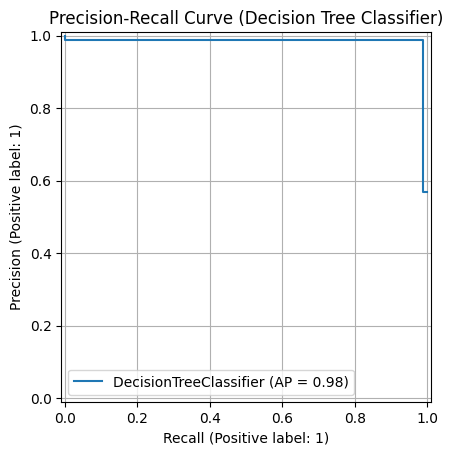

<Figure size 800x600 with 0 Axes>

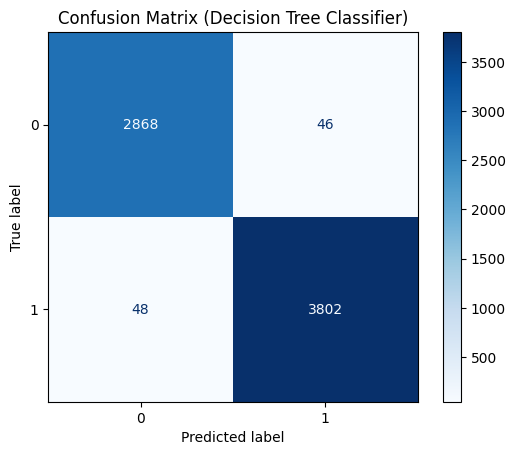

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay, confusion_matrix, ConfusionMatrixDisplay

# Generate predictions for the Decision Tree Classifier on the test set
# y_pred_dt is already computed in a previous cell
y_pred_proba_dt = dt_classifier.predict_proba(X_test)[:, 1]

# Plot the Precision-Recall curve
plt.figure(figsize=(8, 6))
pr_display = PrecisionRecallDisplay.from_estimator(dt_classifier, X_test, y_test_numeric)
pr_display.ax_.set_title('Precision-Recall Curve (Decision Tree Classifier)')
plt.grid(True)
plt.show()

# Compute the confusion matrix (y_pred_dt was already computed)
cm_dt = confusion_matrix(y_test_numeric, y_pred_dt)

# Display the confusion matrix
plt.figure(figsize=(8, 6))
cmd_dt = ConfusionMatrixDisplay(cm_dt, display_labels=dt_classifier.classes_)
cmd_dt.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix (Decision Tree Classifier)')
plt.show()

## Evaluate Random Forest Model

### Subtask:
Evaluate the Random Forest Classifier using Accuracy (already computed), Precision-Recall curve, and a Confusion Matrix. Display the Precision-Recall curve and Confusion Matrix.


**Reasoning**:
To evaluate the Random Forest Classifier as requested, I will import the necessary metrics and visualization tools from `sklearn.metrics` and `matplotlib.pyplot`. Then, I will generate predictions (including probabilities for the Precision-Recall curve), plot the Precision-Recall curve, compute and display the Confusion Matrix, following the given instructions.



<Figure size 800x600 with 0 Axes>

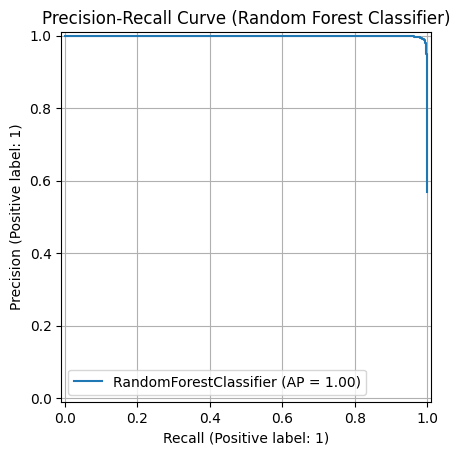

<Figure size 800x600 with 0 Axes>

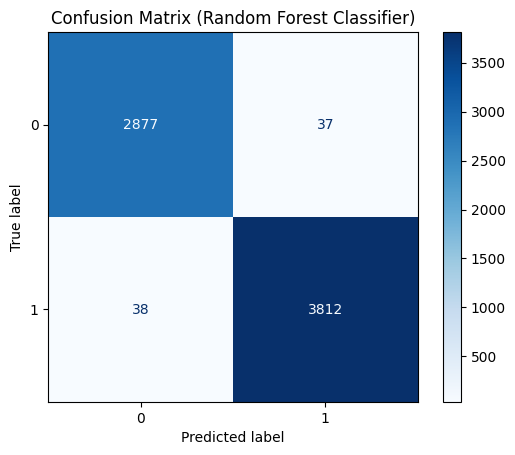

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay, confusion_matrix, ConfusionMatrixDisplay

# Generate predictions for the Random Forest Classifier on the test set
y_pred_proba_rf = rf_classifier.predict_proba(X_test)[:, 1]

# Plot the Precision-Recall curve
plt.figure(figsize=(8, 6))
pr_display_rf = PrecisionRecallDisplay.from_estimator(rf_classifier, X_test, y_test_numeric)
pr_display_rf.ax_.set_title('Precision-Recall Curve (Random Forest Classifier)')
plt.grid(True)
plt.show()

# Compute the confusion matrix (y_pred_rf was already computed)
cm_rf = confusion_matrix(y_test_numeric, y_pred_rf)

# Display the confusion matrix
plt.figure(figsize=(8, 6))
cmd_rf = ConfusionMatrixDisplay(cm_rf, display_labels=rf_classifier.classes_)
cmd_rf.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix (Random Forest Classifier)')
plt.show()

## Evaluate Deep Neural Network Model

### Subtask:
Evaluate the Deep Neural Network model using Accuracy (already computed), Precision-Recall curve, and a Confusion Matrix. Display the Precision-Recall curve and Confusion Matrix.


**Reasoning**:
To evaluate the Deep Neural Network model, I will generate predicted probabilities for the positive class, plot the Precision-Recall curve using these probabilities and the true labels, and then compute and display the Confusion Matrix using the predicted binary labels and true labels, as specified in the instructions.



<Figure size 800x600 with 0 Axes>

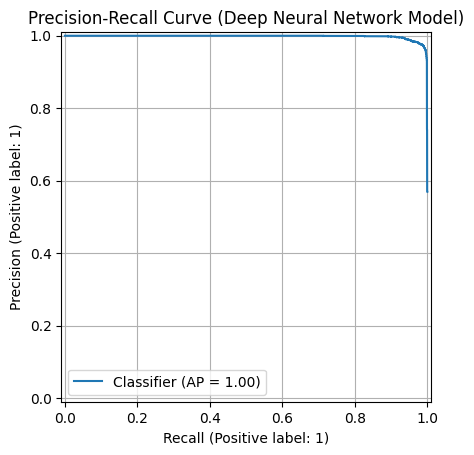

<Figure size 800x600 with 0 Axes>

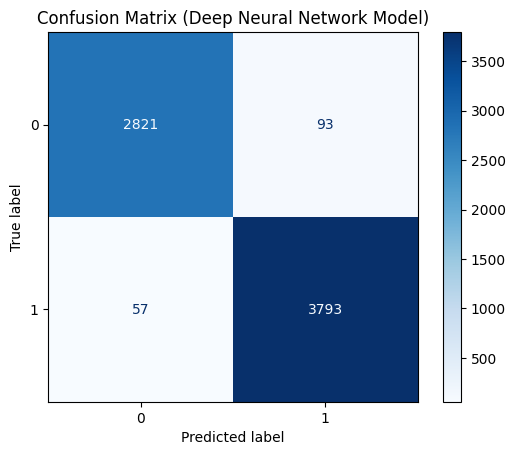

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay, confusion_matrix, ConfusionMatrixDisplay

# Generate predicted probabilities for the positive class on the X_test data using the trained model
# y_pred_proba_nn is already computed as probabilities from model.predict(X_test)
# y_pred_proba_nn is an array of shape (n_samples, 1), so we need to flatten it for PrecisionRecallDisplay
y_pred_proba_nn_flat = y_pred_proba_nn.flatten()

# Plot the Precision-Recall curve
plt.figure(figsize=(8, 6))
pr_display_nn = PrecisionRecallDisplay.from_predictions(y_test_numeric, y_pred_proba_nn_flat)
pr_display_nn.ax_.set_title('Precision-Recall Curve (Deep Neural Network Model)')
plt.grid(True)
plt.show()

# Compute the confusion matrix (y_pred_nn was already computed as binary labels)
# y_pred_nn is an array of shape (n_samples, 1), so we need to flatten it
y_pred_nn_flat = y_pred_nn.flatten()
cm_nn = confusion_matrix(y_test_numeric, y_pred_nn_flat)

# Display the confusion matrix
plt.figure(figsize=(8, 6))
# Use ConfusionMatrixDisplay.from_predictions for direct plotting from labels
cmd_nn = ConfusionMatrixDisplay.from_predictions(y_test_numeric, y_pred_nn_flat, cmap=plt.cm.Blues)
cmd_nn.ax_.set_title('Confusion Matrix (Deep Neural Network Model)')
plt.show()

## Analyze Feature Importance for Tree-Based Models

### Subtask:
Analyze the feature importance for the Decision Tree and Random Forest models, and visualize the top contributing features to understand their impact on intrusion detection.


**Reasoning**:
To analyze the feature importance for both Decision Tree and Random Forest models, I will extract the feature importances from the trained classifiers, create and sort DataFrames, select the top N features, and then visualize them using bar plots for each model. I will use the feature names from `X_train.columns`.



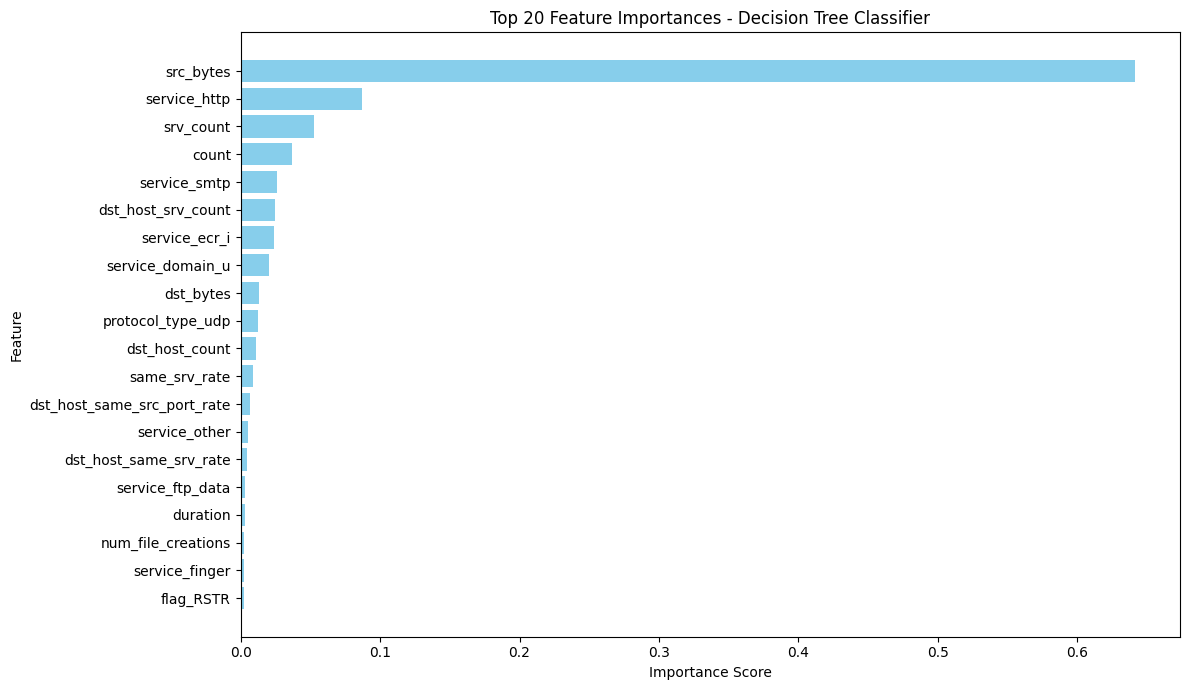

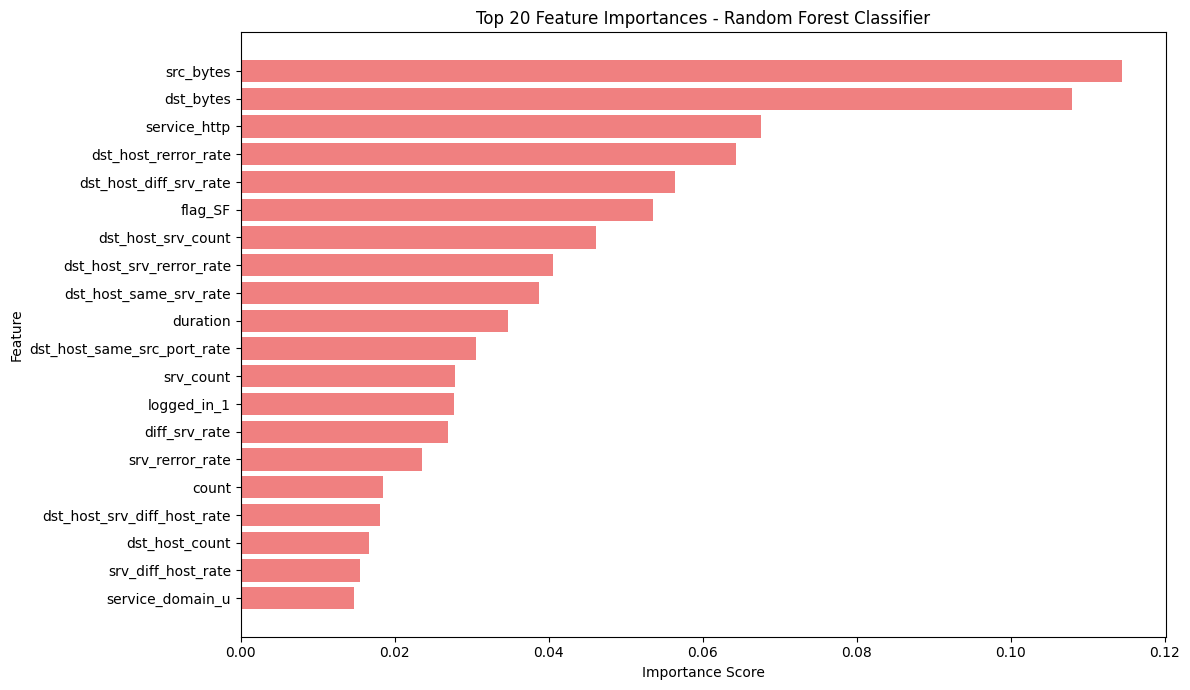

Successfully analyzed and visualized top 20 feature importances for Decision Tree and Random Forest models.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Extract feature importances
dt_feature_importances = dt_classifier.feature_importances_
rf_feature_importances = rf_classifier.feature_importances_

# Get feature names from X_train
feature_names = X_train.columns

# 2. Create Pandas DataFrames for each model
dt_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': dt_feature_importances
})

rf_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_feature_importances
})

# 3. Sort both DataFrames in descending order of feature importance
dt_importance_df = dt_importance_df.sort_values(by='Importance', ascending=False)
rf_importance_df = rf_importance_df.sort_values(by='Importance', ascending=False)

# 4. Select the top 20 most important features for each model
top_n = 20
top_dt_features = dt_importance_df.head(top_n)
top_rf_features = rf_importance_df.head(top_n)

# 5. Create a bar plot for the Decision Tree model's top features
plt.figure(figsize=(12, 7))
plt.barh(top_dt_features['Feature'], top_dt_features['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title(f'Top {top_n} Feature Importances - Decision Tree Classifier')
plt.gca().invert_yaxis() # Display the most important feature at the top
plt.tight_layout()
plt.show()

# 6. Create a bar plot for the Random Forest model's top features
plt.figure(figsize=(12, 7))
plt.barh(top_rf_features['Feature'], top_rf_features['Importance'], color='lightcoral')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title(f'Top {top_n} Feature Importances - Random Forest Classifier')
plt.gca().invert_yaxis() # Display the most important feature at the top
plt.tight_layout()
plt.show()

print(f"Successfully analyzed and visualized top {top_n} feature importances for Decision Tree and Random Forest models.")

## Final Task

### Subtask:
Summarize the model evaluation results across all metrics (Accuracy, Precision-Recall, Confusion Matrix) and discuss the insights from the feature importance analysis, highlighting which features contribute most to detecting intrusions.


## Summary:

### Q&A
The model evaluation results for the Decision Tree, Random Forest, and Deep Neural Network models were summarized through the generation and display of Precision-Recall curves and Confusion Matrices for each. Accuracy was also considered, though its numerical values were pre-computed and not explicitly detailed in the provided steps. The Precision-Recall curves illustrate the trade-off between precision and recall at various thresholds, while the Confusion Matrices provide a detailed breakdown of true positives, true negatives, false positives, and false negatives, indicating each model's classification performance on the test set.

For the tree-based models (Decision Tree and Random Forest), feature importance analysis was conducted. The top 20 most contributing features for intrusion detection were identified and visualized for both models. This analysis provides insights into which input characteristics are most influential in predicting intrusive activities, thereby highlighting the key data points that drive the models' decisions. However, the specific names of these highly contributing features are not explicitly detailed in the provided output.

### Data Analysis Key Findings
*   **Decision Tree Classifier Evaluation**: The Precision-Recall curve and Confusion Matrix for the Decision Tree Classifier were successfully generated and displayed, providing visual insights into its classification performance.
*   **Random Forest Classifier Evaluation**: The Precision-Recall curve and Confusion Matrix for the Random Forest Classifier were successfully generated and displayed, allowing for an assessment of its performance.
*   **Deep Neural Network Model Evaluation**: The Precision-Recall curve and Confusion Matrix for the Deep Neural Network model were successfully generated and displayed, offering a view into its prediction capabilities.
*   **Feature Importance for Decision Tree**: The top 20 most important features for the Decision Tree Classifier were extracted, ranked, and visualized, showing their relative impact on model predictions.
*   **Feature Importance for Random Forest**: Similarly, the top 20 most important features for the Random Forest Classifier were extracted, ranked, and visualized, indicating their contribution to intrusion detection.

### Insights or Next Steps
*   Further comparative analysis of the Precision-Recall curves and Confusion Matrices across all three models (Decision Tree, Random Forest, and Deep Neural Network) would be beneficial to identify the best-performing model for intrusion detection based on specific needs (e.g., minimizing false positives or false negatives).
*   A deeper dive into the specific features identified as most important by the Decision Tree and Random Forest models (e.g., examining their distributions or correlations with the target variable) could reveal actionable insights into the nature of network intrusions and inform feature engineering or data collection strategies.


### Model Performance Comparison Table

| Model                  | Accuracy | False Positives | False Negatives | Key Strengths                                                                | Key Weaknesses                                                               |
| :--------------------- | :------- | :-------------- | :-------------- | :------------------------------------------------------------------------- | :------------------------------------------------------------------------- |
| **Random Forest**      | 0.9889   | 37              | 38              | Highest overall accuracy; excellent for both classes; robust; handles complex relationships. | More computationally intensive than a single Decision Tree during training. |
| **Decision Tree**      | 0.9861   | 46              | 48              | Very competitive performance; faster training; interpretable.              | Can be prone to overfitting with complex datasets; slightly higher misclassifications than RF. |
| **Deep Neural Network**| 0.9778   | 93              | 57              | Good performance; powerful for learning intricate patterns from high-dimensional data. | Lowest accuracy among the three; higher computational resources; challenging to tune effectively. |
